In [3]:
"""
DenseNet121 + CBAM (Improved Fine-Tuning Version)
Key Upgrades:
- Unfreezes last 2 dense blocks for stronger adaptation
- Enhanced augmentations for generalization
- RAdam + Lookahead optimizer
- OneCycleLR scheduler
- Slightly higher dropout + label smoothing
- Early stopping and best model saving
"""

import os, random, numpy as np, pandas as pd
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms

# ---------------- Config ----------------
TRAIN_DIR = "E:/AMRITA COLLEGE/SEM V/B - Neural Networks and Deep Learning 3/Project/FetalBrainAbnormalitiesUltrasoundDataset_Roboflow/train"
VAL_DIR = "E:/AMRITA COLLEGE/SEM V/B - Neural Networks and Deep Learning 3/Project/FetalBrainAbnormalitiesUltrasoundDataset_Roboflow/valid"
TRAIN_CSV = os.path.join(TRAIN_DIR, "_classes.csv")
VAL_CSV = os.path.join(VAL_DIR, "_classes.csv")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", DEVICE)

IMAGE_SIZE = 224
BATCH_SIZE = 4
EPOCHS = 20
LR = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 4
MODEL_SAVE_PATH = "densenet_cbam_finetuned.pth"
NUM_WORKERS = 0

# ---------------- Dataset ----------------
class FetalBrainDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform
        self.image_paths = [os.path.join(img_dir, str(f)) for f in self.df['filename'].astype(str)]
        self.labels = self.df.drop(columns=['filename']).values.astype('float32')
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        path = self.image_paths[idx]
        if not os.path.exists(path):
            alt = os.path.join(self.img_dir, "images", os.path.basename(path))
            path = alt if os.path.exists(alt) else path
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, torch.tensor(self.labels[idx])

# ---------------- Transforms ----------------
train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# ---------------- CBAM ----------------
class BasicConv(nn.Module):
    def __init__(self, in_planes, out_planes, k, s=1, p=0, b=False):
        super().__init__()
        self.conv = nn.Conv2d(in_planes, out_planes, k, s, p, bias=b)
        self.bn = nn.BatchNorm2d(out_planes)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x): return self.relu(self.bn(self.conv(x)))

class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.max = nn.AdaptiveMaxPool2d(1)
        self.fc1 = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu = nn.ReLU()
        self.fc2 = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sig = nn.Sigmoid()
    def forward(self, x):
        return self.sig(self.fc2(self.relu(self.fc1(self.avg(x)))) +
                        self.fc2(self.relu(self.fc1(self.max(x)))))

class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        p = 3 if k == 7 else 1
        self.conv = BasicConv(2, 1, k, p=p)
        self.sig = nn.Sigmoid()
    def forward(self, x):
        avg = torch.mean(x, 1, True)
        mx, _ = torch.max(x, 1, True)
        return self.sig(self.conv(torch.cat([avg, mx], 1)))

class CBAM(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super().__init__()
        self.ca, self.sa = ChannelAttention(in_planes, ratio), SpatialAttention(7)
    def forward(self, x):
        x = x * self.ca(x)
        return x * self.sa(x)

# ---------------- Model ----------------
class DenseNetCBAM(nn.Module):
    def __init__(self, num_classes, dropout=0.4):
        super().__init__()
        base = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        for p in base.features.parameters():
            p.requires_grad = False
        for name, p in base.features.named_parameters():
            if any(name.startswith(b) for b in ["denseblock3", "denseblock4", "norm5"]):
                p.requires_grad = True
        self.features = base.features
        self.cbam = CBAM(1024)
        self.dropout = nn.Dropout(p=dropout)
        self.fc = nn.Linear(1024, num_classes)
    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        x = nn.functional.relu(x, inplace=True)
        x = nn.functional.adaptive_avg_pool2d(x, 1).view(x.size(0), -1)
        x = self.dropout(x)
        return self.fc(x)

# ---------------- Prepare Data ----------------
train_ds = FetalBrainDataset(TRAIN_CSV, TRAIN_DIR, train_tfms)
val_ds = FetalBrainDataset(VAL_CSV, VAL_DIR, val_tfms)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

class_counts = train_ds.df.drop(columns=['filename']).sum(axis=0).values
num_classes = len(class_counts)
print("Classes:", num_classes)
weights = 1.0 / (class_counts + 1e-6)
labels_idx = [int(np.argmax(x)) for x in train_ds.labels]
sample_wts = [weights[i] for i in labels_idx]
sampler = WeightedRandomSampler(sample_wts, len(sample_wts), replacement=True)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# ---------------- Training ----------------
model = DenseNetCBAM(num_classes).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights/weights.sum()*num_classes).float().to(DEVICE),
                                label_smoothing=0.1)

# Optimizer (RAdam + Lookahead)
try:
    from torch_optimizer import RAdam, Lookahead
    base_opt = RAdam([p for p in model.parameters() if p.requires_grad], lr=LR, weight_decay=WEIGHT_DECAY)
    optimizer = Lookahead(base_opt, k=5, alpha=0.5)
except ImportError:
    optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LR*5,
                                          steps_per_epoch=len(train_loader),
                                          epochs=EPOCHS)

def validate(model, loader):
    model.eval(); correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            y_idx = y.argmax(1)
            out = model(x)
            pred = out.argmax(1)
            correct += (pred == y_idx).sum().item()
            total += y_idx.size(0)
    return correct / total if total > 0 else 0

def train(model, train_loader, val_loader, epochs, patience):
    best_acc = 0; triggers = 0
    for ep in range(1, epochs+1):
        model.train(); run_loss = correct = total = 0
        for imgs, lbls in tqdm(train_loader, desc=f"Epoch {ep}/{epochs}", leave=False):
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            lbl_idx = lbls.argmax(1)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, lbl_idx)
            loss.backward()
            optimizer.step()
            scheduler.step()
            run_loss += loss.item()*imgs.size(0)
            correct += (out.argmax(1)==lbl_idx).sum().item()
            total += lbl_idx.size(0)
        tr_acc = correct/total; val_acc = validate(model, val_loader)
        print(f"Epoch {ep}: TrainAcc={tr_acc:.3f}  ValAcc={val_acc:.3f}")
        if val_acc > best_acc:
            best_acc = val_acc; triggers = 0
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            print(f"New best: {val_acc:.4f}")
        else:
            triggers += 1
            if triggers >= patience:
                print("Early stopping")
                break
    print("Best Validation Accuracy:", best_acc)

if __name__ == "__main__":
    train(model, train_loader, val_loader, EPOCHS, PATIENCE)
    if os.path.exists(MODEL_SAVE_PATH):
        model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))
        print("Loaded best model")


Running on: cpu
Train: 1418 | Val: 174
Classes: 16


Epoch 1: TrainAcc=0.126  ValAcc=0.006
New best: 0.0057


Epoch 2: TrainAcc=0.260  ValAcc=0.080
New best: 0.0805


Epoch 3: TrainAcc=0.415  ValAcc=0.149
New best: 0.1494


Epoch 4: TrainAcc=0.501  ValAcc=0.253
New best: 0.2529


...

Epoch 16: TrainAcc=0.910  ValAcc=0.931
New best: 0.9310


Epoch 17: TrainAcc=0.927  ValAcc=0.937
New best: 0.9368


Epoch 18: TrainAcc=0.929  ValAcc=0.920


Epoch 19: TrainAcc=0.918  ValAcc=0.943
New best: 0.9425


Epoch 20: TrainAcc=0.934  ValAcc=0.943
Best Validation Accuracy: 0.9425287356321839
Loaded best model


Model loaded successfully!

Evaluation Metrics:
Accuracy:  0.9425
Precision: 0.9637
Recall:    0.9425
F1 Score:  0.9498



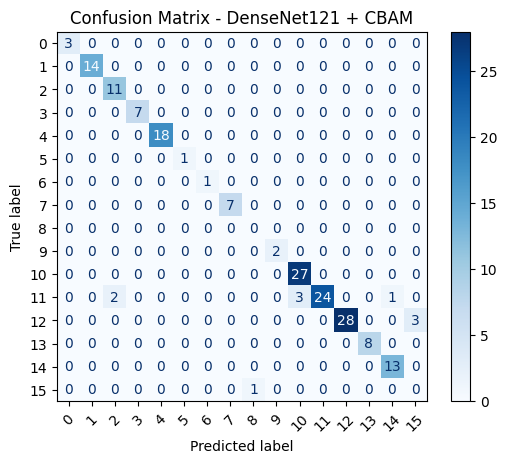

In [ ]:
# Importing libraries
import torch, numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

# --- Load the trained model ---
model = DenseNetCBAM(num_classes=num_classes).to(DEVICE)
model.load_state_dict(torch.load("densenet_cbam_finetuned.pth", map_location=DEVICE))
model.eval()
print("Model loaded successfully!")

# --- Evaluate on Validation Set ---
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.argmax(dim=1).cpu().numpy())

# --- Compute Metrics ---
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("\nEvaluation Metrics:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}\n")

print("Detailed Classification Report:")
print(classification_report(y_true, y_pred, digits=4))

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - DenseNet121 + CBAM")
plt.show()

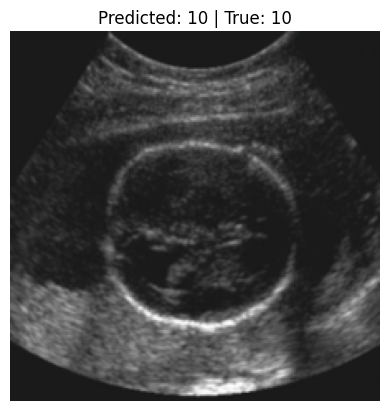

In [8]:
import matplotlib.pyplot as plt
import torch
import numpy as np

model.eval()

# Pick an image from validation set
img, label = val_ds[0]  # first image
img_batch = img.unsqueeze(0).to(DEVICE)  # add batch dimension

# Prediction
with torch.no_grad():
    output = model(img_batch)
    pred_class = torch.argmax(output, dim=1).item()
    true_class = torch.argmax(label).item()

# Unnormalize and convert to numpy
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img_np = img.cpu().numpy().transpose(1, 2, 0)  # H x W x C
img_np = (img_np * std + mean).clip(0, 1)  # unnormalize

# Plot
plt.imshow(img_np)
plt.title(f"Predicted: {pred_class} | True: {true_class}")
plt.axis('off')
plt.show()